<a href="https://colab.research.google.com/github/Xuan09-30/Simple-Climate-Analysis/blob/main/Simple_Climate_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", palette="muted")

In [24]:
import requests
import pandas as pd

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=3.1390&longitude=101.6869&"
    "start_date=2023-01-01&end_date=2023-12-31&"
    "daily=temperature_2m_mean,precipitation_sum&"
    "timezone=Asia%2FSingapore"
)

print("Fetching real historical weather data for Kuala Lumpur...")
response = requests.get(url).json()

daily_data = pd.DataFrame(response['daily'])
daily_data['time'] = pd.to_datetime(daily_data['time'])

daily_data['Month_Num'] = daily_data['time'].dt.month
daily_data['Month'] = daily_data['time'].dt.strftime('%b')

df_weather = daily_data.groupby(['Month_Num', 'Month']).agg({
    'precipitation_sum': 'sum',
    'temperature_2m_mean': 'mean'
}).reset_index()

df_weather.rename(columns={
    'precipitation_sum': 'Total_Rainfall_mm',
    'temperature_2m_mean': 'Avg_Temperature_C'
}, inplace=True)

df_weather.head(6)

Fetching real historical weather data for Kuala Lumpur...


,Month_Num,Month,Total_Rainfall_mm,Avg_Temperature_C
0,1,Jan,195.1,25.925806
1,2,Feb,181.8,26.328571
2,3,Mar,160.1,26.948387
3,4,Apr,235.1,27.573333
4,5,May,162.5,28.061290
5,6,Jun,167.4,28.146667


In [25]:
correlation = df_weather['Total_Rainfall_mm'].corr(df_weather['Avg_Temperature_C'])
print(f"Pearson Correlation (Rainfall vs. Temperature): {correlation:.4f}")

Pearson Correlation (Rainfall vs. Temperature): -0.4118


In [26]:
def identify_monsoon_phase(month_num):
    if month_num in [11, 12, 1, 2, 3]:
        return "Northeast Monsoon"
    elif month_num in [5, 6, 7, 8, 9]:
        return "Southwest Monsoon"
    else:
        return "Inter-Monsoon"

df_weather['Monsoon_Phase'] = df_weather['Month_Num'].apply(identify_monsoon_phase)
df_weather[['Month', 'Total_Rainfall_mm', 'Monsoon_Phase']].head()

,Month,Total_Rainfall_mm,Monsoon_Phase
0,Jan,195.1,Northeast Monsoon
1,Feb,181.8,Northeast Monsoon
2,Mar,160.1,Northeast Monsoon
3,Apr,235.1,Inter-Monsoon
4,May,162.5,Southwest Monsoon


In [27]:
avg_rainfall_per_monsoon = df_weather.groupby('Monsoon_Phase')['Total_Rainfall_mm'].mean().reset_index()
display(avg_rainfall_per_monsoon)

,Monsoon_Phase,Total_Rainfall_mm
0,Inter-Monsoon,359.85
1,Northeast Monsoon,267.34
2,Southwest Monsoon,223.22


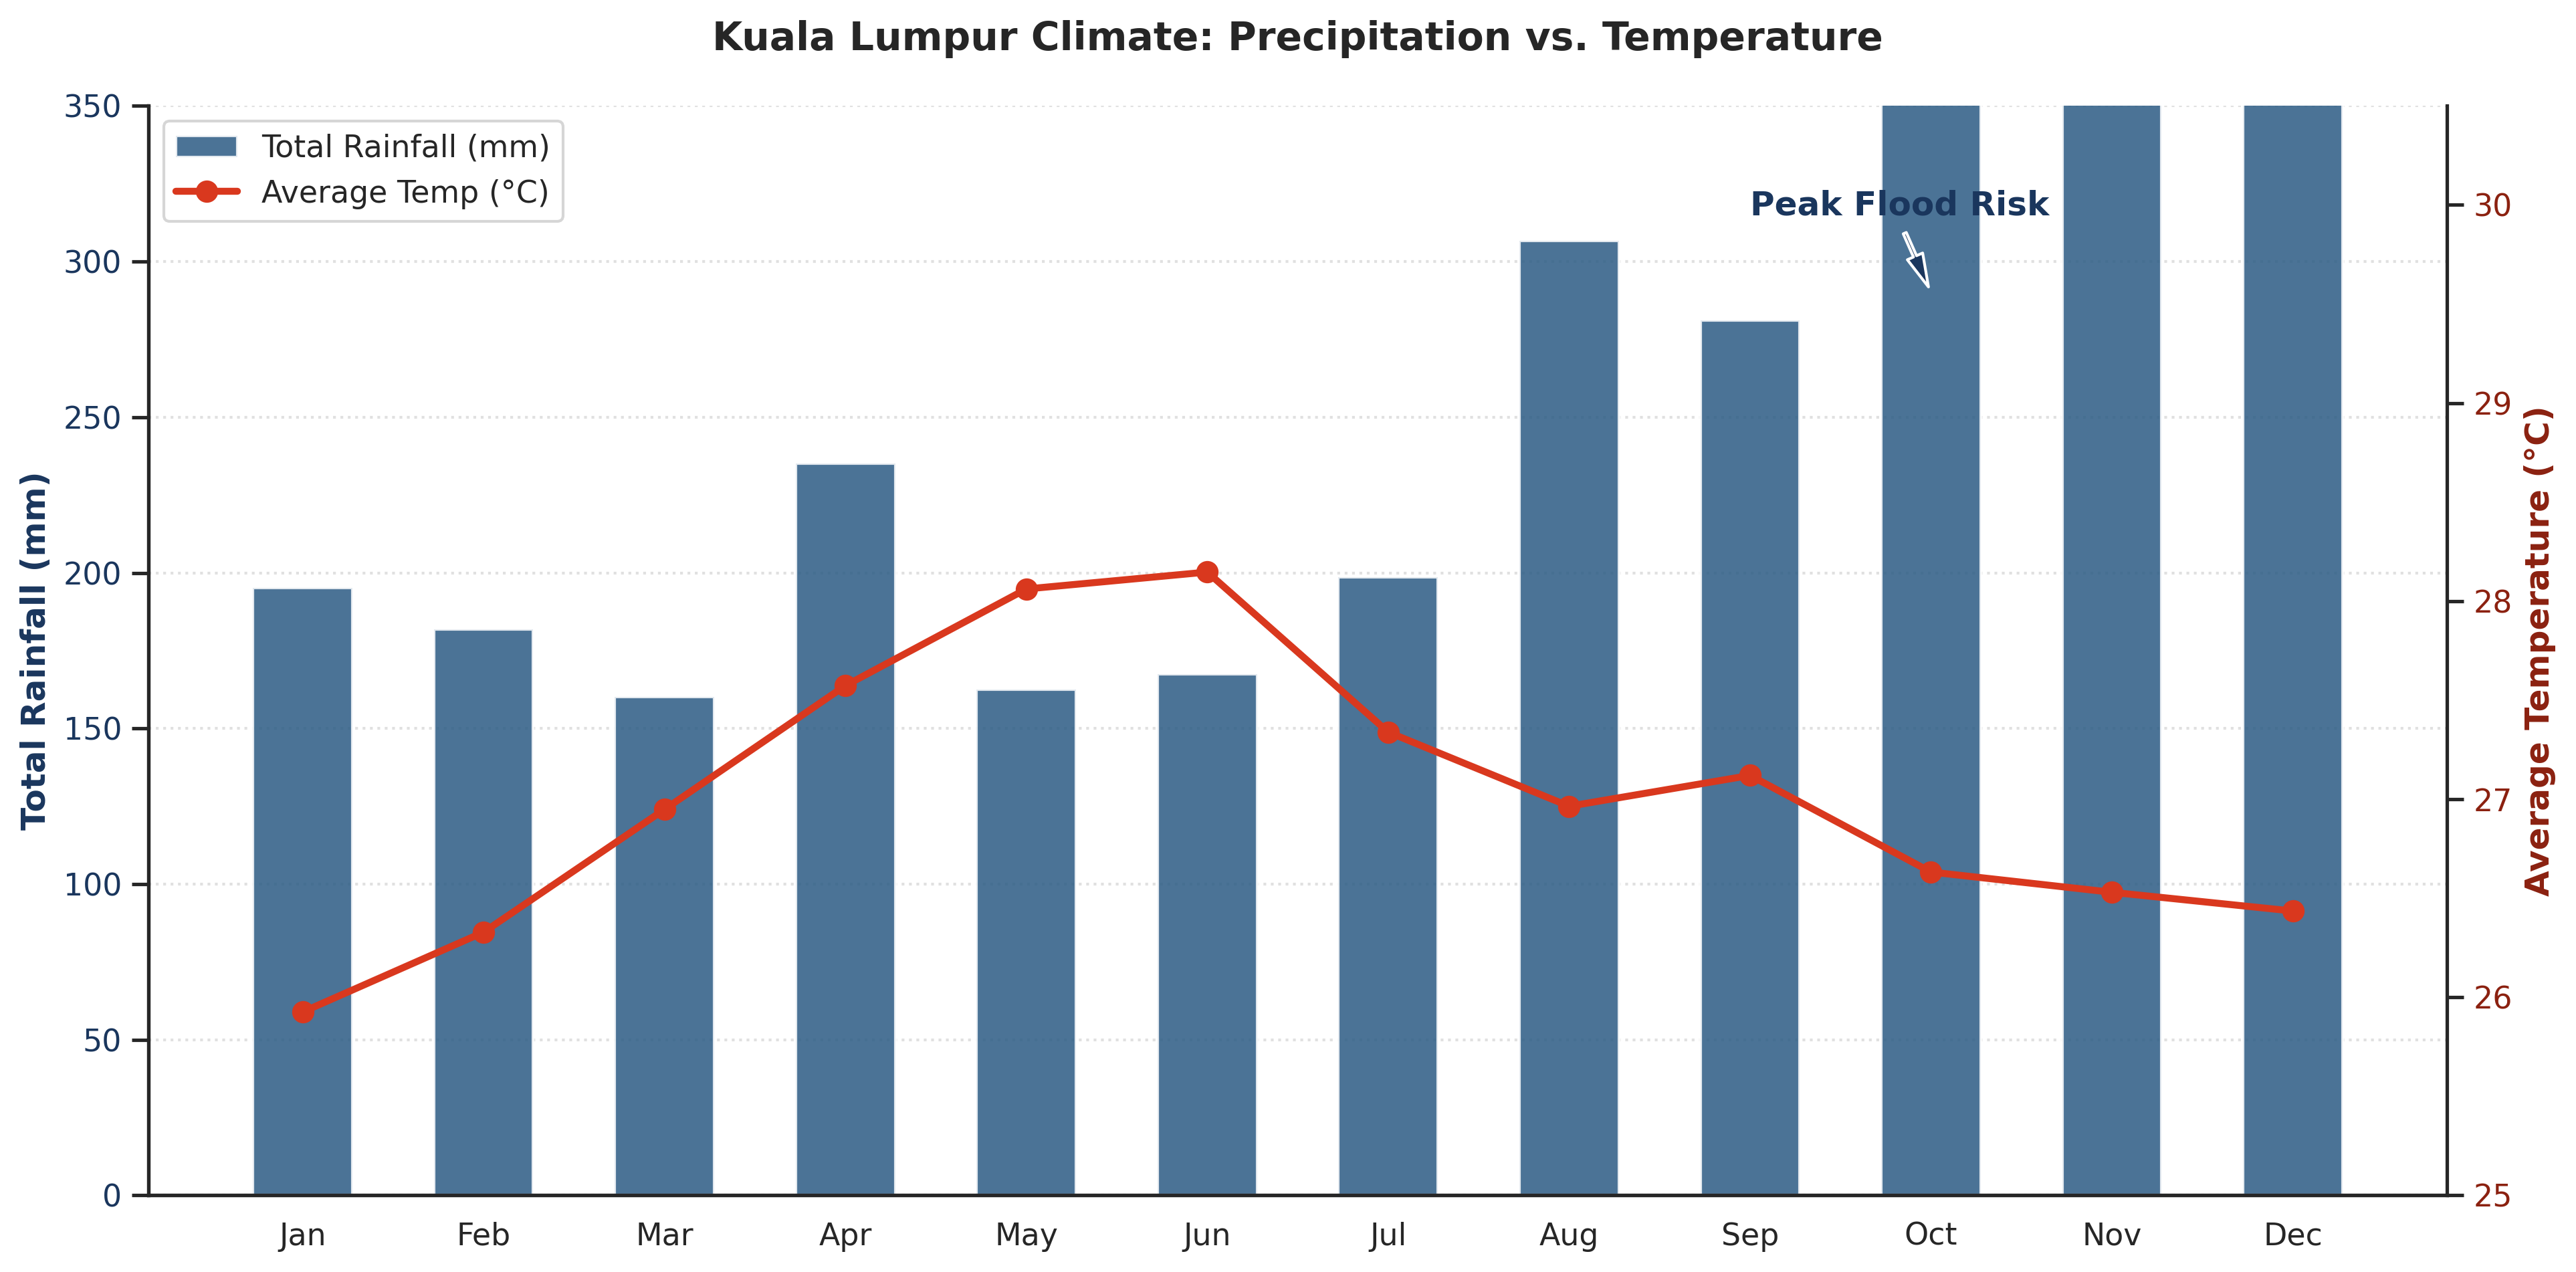

In [28]:
fig, ax_rain = plt.subplots(figsize=(13, 6.5), dpi=300)

ax_rain.bar(
    df_weather['Month'],
    df_weather['Total_Rainfall_mm'],
    color='#2B5B84', alpha=0.85, width=0.55, label='Total Rainfall (mm)'
)
ax_rain.set_ylabel('Total Rainfall (mm)', color='#1A365D', fontsize=12, fontweight='bold')
ax_rain.tick_params(axis='y', labelcolor='#1A365D')
ax_rain.set_ylim(0, 350)
ax_rain.grid(axis='y', linestyle=':', alpha=0.6)

ax_temp = ax_rain.twinx()
ax_temp.plot(
    df_weather['Month'], df_weather['Avg_Temperature_C'],
    color='#D9381E', marker='o', markersize=7, linewidth=2.5, label='Average Temp (°C)'
)
ax_temp.set_ylabel('Average Temperature (°C)', color='#8B2110', fontsize=12, fontweight='bold')
ax_temp.tick_params(axis='y', labelcolor='#8B2110')
ax_temp.set_ylim(25.0, 30.5)

peak_idx = df_weather['Total_Rainfall_mm'].idxmax()
ax_rain.annotate(
    'Peak Flood Risk', xy=(peak_idx, 290), xytext=(peak_idx - 1, 315),
    arrowprops=dict(facecolor='#1A365D', shrink=0.08, width=1.2, headwidth=6),
    fontweight='bold', color='#1A365D'
)

plt.title('Kuala Lumpur Climate: Precipitation vs. Temperature', fontsize=14, fontweight='bold', pad=20)
lines_1, labels_1 = ax_rain.get_legend_handles_labels()
lines_2, labels_2 = ax_temp.get_legend_handles_labels()
ax_rain.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

sns.despine(ax=ax_rain, top=True)
sns.despine(ax=ax_temp, top=True, right=False)
plt.tight_layout()
plt.savefig('kl_climate_dual_axis.png')
plt.show()